# 03 - Analisis exploratorio

La guia pide incluir analisis univariado, bivariado y multivariado con interpretacion. Para que la estructura sea clara y defendible, este notebook usa exactamente 5 visualizaciones: 2 univariadas, 2 bivariadas y 1 multivariada.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path("..").resolve()
df = pd.read_csv(ROOT / "data" / "processed" / "streaming_users_processed.csv")
df.head()


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,4
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


In [2]:
df[["age", "monthly_watch_time_mins", "customer_support_tickets"]].describe().round(2)


,age,monthly_watch_time_mins,customer_support_tickets
count,8000.00,8000.00,8000.00
mean,33.71,802.28,0.83
std,11.46,472.36,0.93
min,13.00,0.00,0.00
25%,26.00,498.88,0.00
50%,33.00,772.20,1.00
75%,41.00,1062.30,1.00
max,80.00,3080.00,4.00


## 1. Univariado: distribucion del tiempo mensual

Pregunta: como se distribuye el consumo mensual de los usuarios?


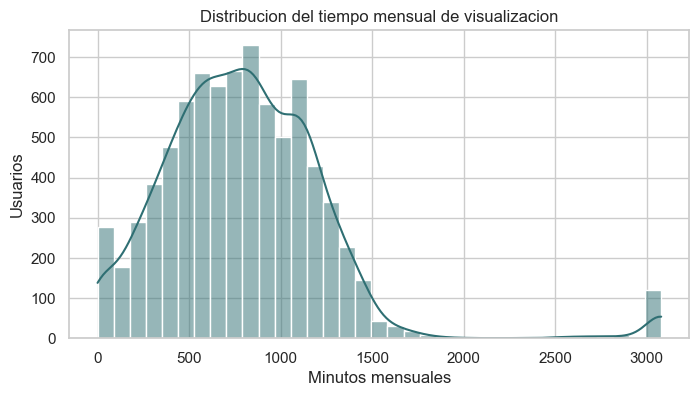

In [3]:
plt.figure(figsize=(8,4))
sns.histplot(df["monthly_watch_time_mins"], bins=35, kde=True, color="#2f6f73")
plt.title("Distribucion del tiempo mensual de visualizacion")
plt.xlabel("Minutos mensuales")
plt.ylabel("Usuarios")
plt.show()


Interpretacion: la mayoria de usuarios se concentra en consumos medios, con una cola de usuarios intensivos. Esto justifica usar medidas robustas como la mediana y no depender solo del promedio.


## 2. Univariado: usuarios por plan

Pregunta: como esta compuesta la base segun plan de suscripcion?


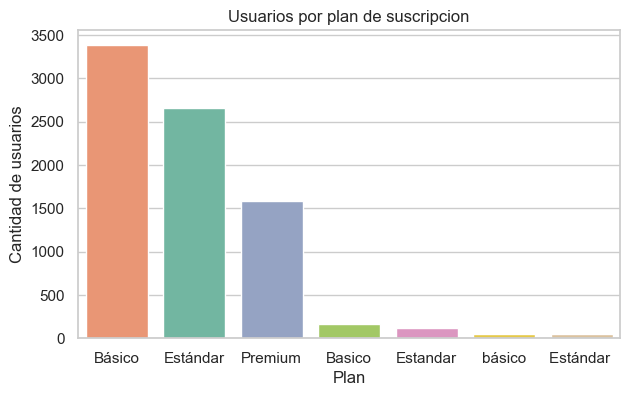

In [4]:
plt.figure(figsize=(7,4))
orden = df["subscription_plan"].value_counts().index
sns.countplot(data=df, x="subscription_plan", order=orden, hue="subscription_plan", palette="Set2", legend=False)
plt.title("Usuarios por plan de suscripcion")
plt.xlabel("Plan")
plt.ylabel("Cantidad de usuarios")
plt.show()


Interpretacion: conocer el volumen de usuarios por plan ayuda a contextualizar comparaciones posteriores. Si un segmento pesa mas, puede influir en la lectura general del dataset.


## 3. Bivariado: edad y consumo mensual

Pregunta: la edad se relaciona claramente con el consumo mensual?


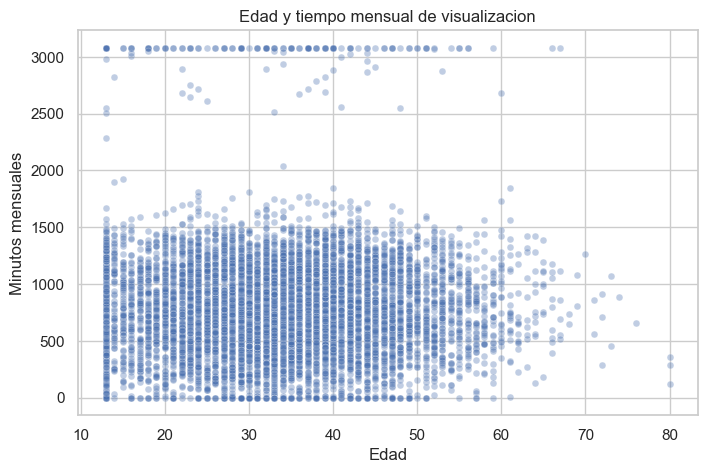

Correlacion edad-consumo: 0.007


In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="monthly_watch_time_mins", alpha=0.35, s=24)
plt.title("Edad y tiempo mensual de visualizacion")
plt.xlabel("Edad")
plt.ylabel("Minutos mensuales")
plt.show()
print("Correlacion edad-consumo:", round(df["age"].corr(df["monthly_watch_time_mins"]), 3))


Interpretacion: la dispersion permite ver que la edad aporta contexto, pero no explica por si sola el consumo. Esto abre la necesidad de mirar variables de segmentacion como plan o genero favorito.


## 4. Bivariado: consumo mensual por plan

Pregunta: el consumo cambia segun el plan de suscripcion?


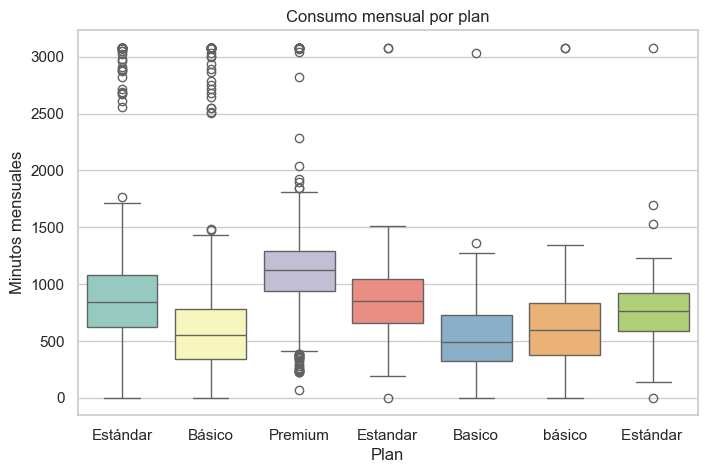

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="subscription_plan", y="monthly_watch_time_mins", hue="subscription_plan", palette="Set3", legend=False)
plt.title("Consumo mensual por plan")
plt.xlabel("Plan")
plt.ylabel("Minutos mensuales")
plt.show()


Interpretacion: el boxplot compara medianas y dispersion entre planes. Si un plan presenta una mediana mas alta, puede sugerir usuarios mas intensivos dentro de ese segmento.


## 5. Multivariado: edad, consumo y genero favorito

Pregunta: los patrones de consumo por edad cambian segun el genero favorito?


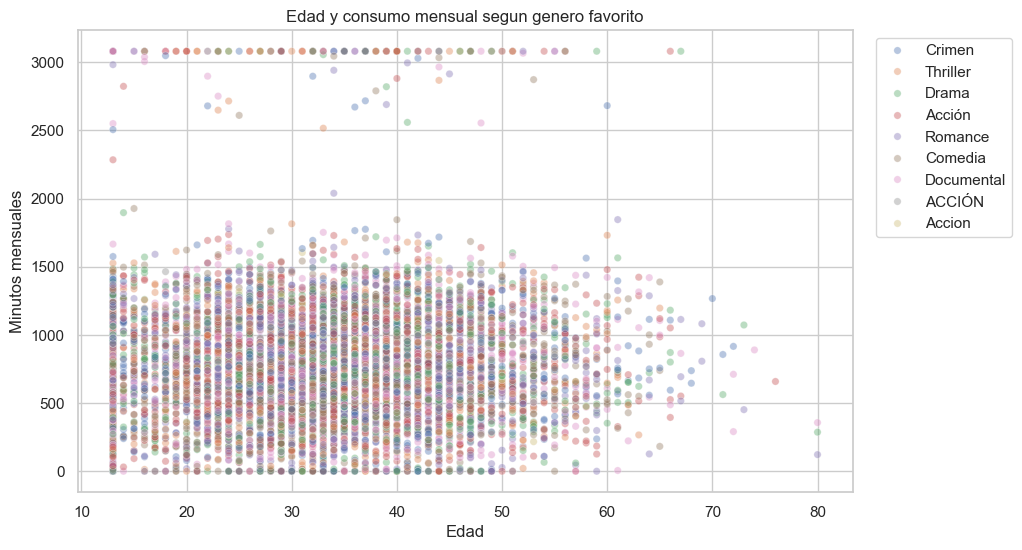

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="age", y="monthly_watch_time_mins", hue="favorite_genre", alpha=0.4, s=28)
plt.title("Edad y consumo mensual segun genero favorito")
plt.xlabel("Edad")
plt.ylabel("Minutos mensuales")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


In [8]:
resumen_genero = (
    df.groupby("favorite_genre")
      .agg(
          usuarios=("user_id", "count"),
          edad_mediana=("age", "median"),
          consumo_mediano=("monthly_watch_time_mins", "median"),
          consumo_promedio=("monthly_watch_time_mins", "mean")
      )
      .sort_values("consumo_mediano", ascending=False)
      .round(2)
)
resumen_genero


,usuarios,edad_mediana,consumo_mediano,consumo_promedio
favorite_genre,,,,
ACCIÓN,14,30.5,928.95,1093.34
Accion,30,35.0,897.30,947.69
Documental,1143,33.0,800.50,823.77
Crimen,1110,34.0,782.70,808.26
Thriller,1140,33.0,781.05,823.19
Drama,1134,34.0,767.95,803.18
Acción,1091,33.0,757.30,789.32
Romance,1160,33.5,757.25,775.33
Comedia,1178,33.0,756.95,786.09


Interpretacion: agregar genero favorito permite una lectura de perfil. Si algun genero concentra mayor consumo mediano, puede orientar preguntas sobre preferencias, permanencia y estrategia de contenido. La tabla resume esa lectura con evidencia numerica.
